# Optuna XGBoost using GPU

This model is only going to be a small deviation from the basic XGBoost Optuna model\. The only different is we will be redirecting the processing for the training of the model to the GPU\. This will only effect the training, so some aspect will still be using the CPU\.

### Imports

In [3]:
import pandas as pd
import numpy as np
import time
import optuna
import optuna.visualization as vis

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.utils import shuffle

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

from optuna.integration import XGBoostPruningCallback

/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load and Shuffle Data

In [4]:
df = pd.read_csv("housing_cleaned.csv")
df = shuffle(df, random_state=42)

In [5]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Optuna XGBoost GPU Model

In [6]:
start = time.time()

In [7]:
# 🔧 Split again for validation (like before)
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [8]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
        'max_depth': trial.suggest_int('max_depth', 4, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
    }

    model = XGBRegressor(
        **params,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        device='cuda',          # HERE: This small change is what redirects the training to the GPU
        tree_method='hist',     
        early_stopping_rounds=20
    )

    model.fit(
        X_train2,
        y_train2,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)
    rmse = mean_squared_error(y_val, preds, squared=False)

    return rmse

In [9]:
study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=100, n_jobs=-1)

[I 2026-04-20 00:59:31,434] A new study created in memory with name: no-name-679a41a1-f183-484a-9546-652afa9bc958
[00:59:32] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
[00:59:32] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
[00:59:32] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
[00:59:32] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
[00:59:32] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
[00:59:32] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
[00:59:32] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
[00:59:32]

In [10]:
end = time.time()
print(f"Total time: {(end - start)/60:.2f} minutes")

Total time: 3.92 minutes


### Extract Best Hyperparameter Values from Tuning

In [11]:
print("Best Params:")
print(study.best_params)

print("Best RMSE:")
print(study.best_value)

Best Params:
{'n_estimators': 868, 'max_depth': 6, 'learning_rate': 0.03661815210740901, 'subsample': 0.8203501291321722, 'colsample_bytree': 0.6226117316289235, 'min_child_weight': 3}
Best RMSE:
0.1582855750802817


### Optuna Specific Visulizations

In [12]:
vis.plot_optimization_history(study)

In [13]:
vis.plot_param_importances(study)

In [14]:
vis.plot_slice(study, params=['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'min_child_weight'])

### Create Model Using Best Parameters

In [15]:
best_params = study.best_params

# Validation split again
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

best_model = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42,
    device='cuda',
    tree_method='hist',
    early_stopping_rounds=20
)

best_model.fit(
    X_train2,
    y_train2,
    eval_set=[(X_train2, y_train2), (X_val, y_val)],
    verbose=False
)

/root/venv/lib/python3.11/site-packages/xgboost/callback.py:385: UserWarning:

[01:03:27] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.

/root/venv/lib/python3.11/site-packages/xgboost/callback.py:385: UserWarning:

[01:03:27] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6226117316289235, device='cuda',
             early_stopping_rounds=20, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03661815210740901,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=868, n_jobs=None,
             num_parallel_tree=None, ...)

### Results

In [16]:
y_pred = best_model.predict(X_test)

rmse_log = mean_squared_error(y_test, y_pred, squared=False)
print("Test RMSE (log scale):", rmse_log)

Test RMSE (log scale): 0.15772080121632676


In [ ]:
# Convert Log RMSE to something easier to interpert.
print(math.exp(rmse_log))

### Visualize the Results

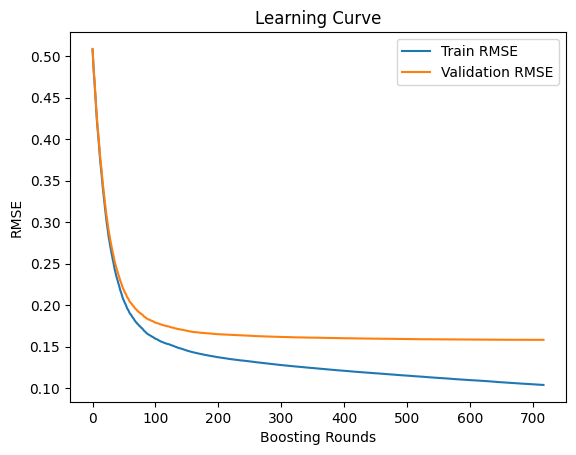

In [17]:
results = best_model.evals_result()

train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

plt.figure()
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse, label='Validation RMSE')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('Learning Curve')
plt.legend()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=89799500-4443-401d-b5a6-3a6742d3b89e' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>